In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
import statsmodels.api as sm
import numpy as np


In [ ]:
file_path = "/content/drive/MyDrive/Analisis matemático/FINALMODELOajustelocal.csv"
df_modelo = pd.read_csv(file_path, encoding='latin1')

In [ ]:
df_modelo["LOG_POBLACION_TOTAL"] = np.log(df_modelo["POBLACION_TOTAL"].replace(0, np.nan))
df_modelo["LOG_POBLACION_20_24"] = np.log(df_modelo["POBLACION_20_24"].replace(0, np.nan))


In [ ]:
df_modelo

,COUNTRY,YEAR,POBLACION_0_14,POBLACION_TOTAL,PIB_POR_PAIS,TASA_MORTALIDAD_INFANTIL,POBLACION_20_24_VARONES,POBLACION_20_24_MUJERES,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,MEDALLAS_DE_ORO_TOTALES_POR_PAIS_POR_AÑO,...,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS,BOICOT_1980,BOICOT_1984,DUMMY_AUSTRALIA,DUMMY_UK,DUMMY_CHINA_MODERNA,DUMMY_FRANCE,LOG_POBLACION_TOTAL,LOG_POBLACION_20_24
0,Afghanistan,2008,13043065,26482622.0,381.733238,69.6,8.50,8.33,1,0,...,2.871497,1.871497,0,0,0,0,0,0,17.091999,15.309992
1,Afghanistan,2012,14548198,30560034.0,651.417134,60.1,9.06,8.89,1,0,...,2.942766,1.942766,0,0,0,0,0,0,17.235204,15.517624
2,Albania,2024,467968,2745972.0,8575.171134,8.4,7.40,6.80,2,0,...,6.640047,4.640047,0,0,0,0,0,0,14.825646,12.873717
3,Algeria,1984,9580584,21271969.0,2524.380714,67.7,9.51,9.02,2,0,...,3.328880,1.328881,0,1,0,0,0,0,16.872901,15.187122
4,Algeria,1992,10910578,26628568.0,1802.693008,42.1,9.95,9.53,2,1,...,4.585902,2.585902,0,0,0,0,0,0,17.097495,15.461713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054,Zambia,1996,4343670,9004053.0,399.511305,100.3,9.72,9.46,1,0,...,2.032876,1.032876,0,0,0,0,0,0,16.013185,14.361883
1055,Zambia,2024,8694765,20723965.0,1330.727806,40.9,9.41,9.37,1,0,...,4.056975,3.056975,0,0,0,0,0,0,16.846801,15.174424
1056,Zimbabwe,1980,3428620,7041303.0,948.527311,70.5,7.87,9.40,15,15,...,3.164395,11.835605,1,0,0,0,0,0,15.767304,14.011105
1057,Zimbabwe,2004,5154172,12365896.0,469.484654,51.6,11.68,12.62,3,1,...,3.655562,0.655562,0,0,0,0,0,0,16.330453,14.915759


In [ ]:
# 1. Crear nuevos dummies

# China moderna (año >= 2000)
df_modelo["DUMMY_CHINA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "China" and row["YEAR"] >= 2008 else 0, axis=1)
df_modelo["DUMMY_KOREA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "South Korea" and row["YEAR"] >= 1988 else 0, axis=1)

# Francia (en general)
df_modelo["DUMMY_FRANCE"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "France" else 0)
df_modelo["DUMMY_ITALY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Italy" else 0)
df_modelo["DUMMY_HUNGARY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Hungary" else 0)
df_modelo["DUMMY_JAPAN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Japan" else 0)
df_modelo["DUMMY_BULGARIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Bulgaria" else 0)
df_modelo["DUMMY_CUBA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Cuba" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_ROMANIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Romania" else 0)
df_modelo["DUMMY_SPAIN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Spain" else 0)
df_modelo["DUMMY_SERBIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Serbia" else 0)
df_modelo["DUMMY_CANADA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Canada" else 0)
df_modelo["DUMMY_BRAZIL"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Brazil" else 0)
df_modelo["DUMMY_POLAND"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Poland" else 0)
# 2. Redefinir X con las nuevas variables
X = df_modelo[[
    "LOG_PIB_REAL",
    #"LOG_POBLACION_TOTAL",
    "LOG_POBLACION_20_24",
    "TASA_MORTALIDAD_INFANTIL_CENTRADO",
    "LOCAL",
    "VECINO",
   "DUMMY_CHINA_MODERNA",
    "DUMMY_RUSSIA",
    "DUMMY_USA",
    "DUMMY_GERMANY",
   # "BOICOT_1980",
   # "BOICOT_1984",
    "DUMMY_AUSTRALIA",
    "DUMMY_UK",
    "DUMMY_FRANCE",
    "DUMMY_ITALY",
    "DUMMY_HUNGARY",
    "DUMMY_JAPAN",
  #   "DUMMY_BULGARIA",
  #   "DUMMY_CUBA",
     "DUMMY_KOREA_MODERNA",
     "DUMMY_NETHERLANDS",
  #   "DUMMY_ROMANIA",
  #   "DUMMY_SPAIN",
    "DUMMY_SERBIA",
     "DUMMY_CANADA",
     "DUMMY_BRAZIL"
  #   "DUMMY_POLAND"

]]

# 3. Agregar constante
X = sm.add_constant(X)

# 4. Definir y
y= df_modelo["LOG_PROP_MEDALLAS"]

# 5. Ajustar el modelo
modelo = sm.OLS(y, X).fit()

# 6. Mostrar el resumen del modelo
print(modelo.summary())



                            OLS Regression Results                            
Dep. Variable:      LOG_PROP_MEDALLAS   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     66.41
Date:                Thu, 01 May 2025   Prob (F-statistic):          8.62e-170
Time:                        22:31:57   Log-Likelihood:                -1549.4
No. Observations:                1059   AIC:                             3141.
Df Residuals:                    1038   BIC:                             3245.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [ ]:
import numpy as np

# 1. Predecir log(ŵ_it) con el modelo
log_predicciones = modelo.predict(X)

# 2. Destransformar: volver a escala real (ŵ_it)
predicciones = np.exp(log_predicciones)

# 3. Agregar las predicciones al dataframe de modelado
df_modelo["PROP_MEDALLAS_PREDICHA"] = predicciones

# 4. Opcional: calcular error absoluto entre proporción real y predicha
df_modelo["ERROR_ABSOLUTO"] = np.abs(df_modelo["PROP_MEDALLAS"] - df_modelo["PROP_MEDALLAS_PREDICHA"])

# 5. Mostrar ejemplo de tabla de resultados
resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_TOTALES_POR_PAIS_POR_AÑO",
    "PROP_MEDALLAS",
    "PROP_MEDALLAS_PREDICHA",
    "ERROR_ABSOLUTO"
]].sort_values(by="ERROR_ABSOLUTO", ascending=False)

# Mostrar los 10 países con mayor error
resultados.head(10)


,COUNTRY,YEAR,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,PROP_MEDALLAS,PROP_MEDALLAS_PREDICHA,ERROR_ABSOLUTO
797,Russia,1980,442,0.319134,0.140631,0.178502
354,Germany,1976,273,0.206818,0.116897,0.089921
353,Germany,1972,253,0.208230,0.118931,0.089299
1019,United States,1984,352,0.238644,0.158974,0.079670
357,Germany,1988,296,0.187223,0.110823,0.076400
355,Germany,1980,264,0.190614,0.118828,0.071786
781,Romania,1984,106,0.071864,0.002568,0.069297
796,Russia,1976,286,0.216667,0.147736,0.068930
1018,United States,1976,164,0.124242,0.192972,0.068730
798,Russia,1988,300,0.189753,0.122918,0.066835


In [ ]:
# 1. Primero, recuperar el total de medallas entregadas cada año
total_medallas_por_ano = df_modelo.groupby("YEAR")["MEDALLAS_TOTALES_POR_PAIS_POR_AÑO"].transform("sum")

# 2. Calcular las medallas reales y predichas en números absolutos
df_modelo["MEDALLAS_REALES"] = df_modelo["PROP_MEDALLAS"] * total_medallas_por_ano
df_modelo["MEDALLAS_PREDICHAS"] = df_modelo["PROP_MEDALLAS_PREDICHA"] * total_medallas_por_ano

# 3. Calcular error absoluto en número de medallas
df_modelo["ERROR_ABSOLUTO_MEDALLAS"] = np.abs(df_modelo["MEDALLAS_REALES"] - df_modelo["MEDALLAS_PREDICHAS"])

# 4. Armar la tabla ordenada
tabla_resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_REALES",
    "MEDALLAS_PREDICHAS",
    "ERROR_ABSOLUTO_MEDALLAS"
]].sort_values(by="ERROR_ABSOLUTO_MEDALLAS", ascending=False)

# 5. Mostrar los 10 países con mayor error absoluto
tabla_resultados.head(15)


,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
797,Russia,1980,442.000000,194.774155,247.225845
357,Germany,1988,295.999999,175.210903,120.789096
354,Germany,1976,273.000000,154.303976,118.696024
1019,United States,1984,352.000000,234.487242,117.512758
803,Russia,2008,141.999999,251.232836,109.232837
353,Germany,1972,253.000000,144.501342,108.498658
798,Russia,1988,300.000001,194.333981,105.666020
781,Romania,1984,106.000000,3.787101,102.212899
1013,United Kingdom,2024,156.000000,55.018629,100.981370
355,Germany,1980,263.999999,164.576725,99.423274


In [ ]:
tabla_resultados.to_excel("MODELO2AÑOS.xlsx", index=False)

In [ ]:
df=tabla_resultados

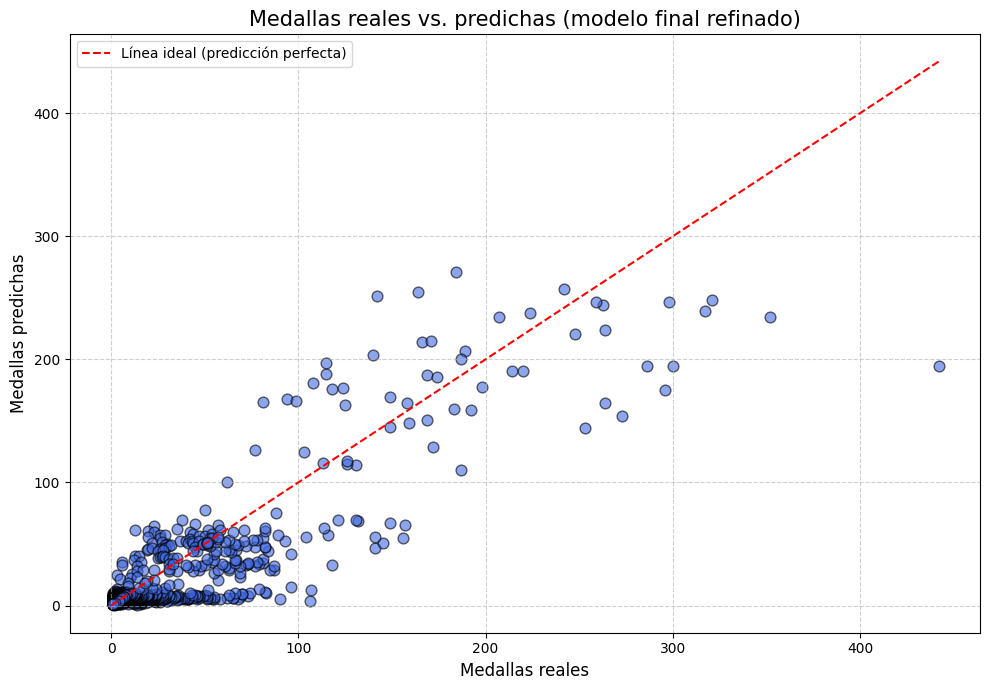

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar archivo de resultados
#df = pd.read_excel("RESULTADOS5.xlsx")  # Asegúrate de tener este archivo en tu carpeta de trabajo

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# 3. Seleccionar las columnas necesarias y eliminar valores nulos
df_grafico = df[["COUNTRY", "YEAR", "MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].dropna()

# 4. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_grafico["MEDALLAS_REALES"],
    df_grafico["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='royalblue',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, df_grafico["MEDALLAS_REALES"].max()],
    [0, df_grafico["MEDALLAS_REALES"].max()],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 5. Etiquetas y formato
plt.title("Medallas reales vs. predichas (modelo final refinado)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Mostrar
plt.show()


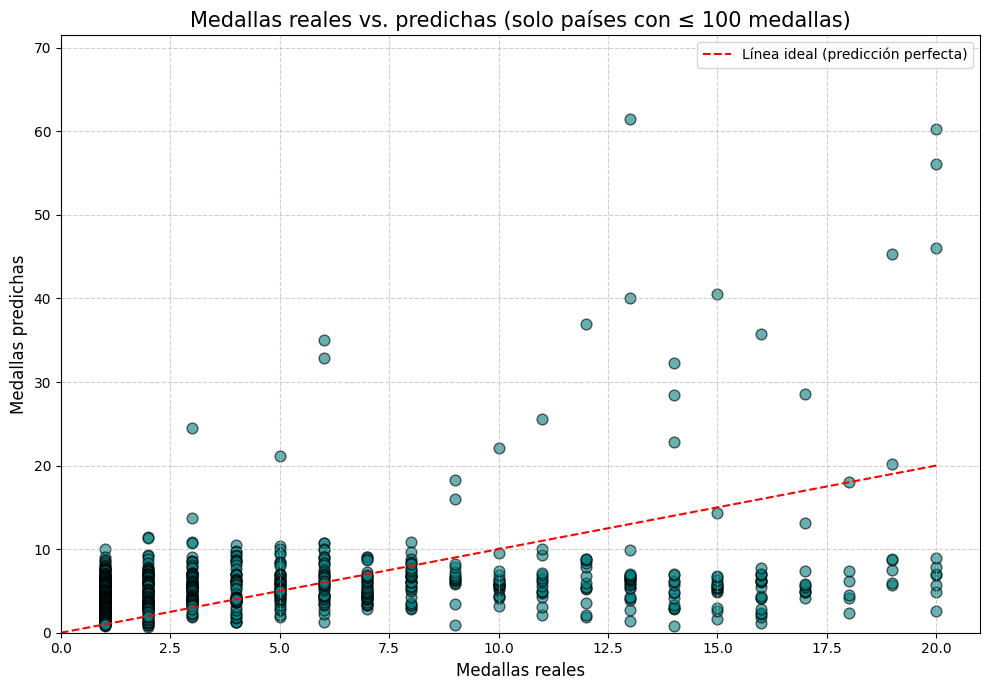

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar datos
df.columns = df.columns.str.strip()

# 2. Filtrar solo países con hasta 100 medallas reales
df_sub = df[df["MEDALLAS_REALES"] <= 20].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_sub["MEDALLAS_REALES"],
    df_sub["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='teal',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, 20],
    [0, 20],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 4. Etiquetas y formato
plt.title("Medallas reales vs. predichas (solo países con ≤ 100 medallas)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.xlim(0, 21)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 5. Mostrar
plt.show()


In [ ]:
import pandas as pd

# 1. Cargar archivo de resultados
df.columns = df.columns.str.strip()

# 2. Agrupar por país y sumar medallas reales y predichas
tabla_resumen = df.groupby("COUNTRY")[["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].sum().reset_index()

# 3. Calcular el error absoluto total por país
tabla_resumen["ERROR_ABSOLUTO_TOTAL"] = abs(tabla_resumen["MEDALLAS_REALES"] - tabla_resumen["MEDALLAS_PREDICHAS"])

# 4. Renombrar columnas para claridad
tabla_resumen.columns = ["COUNTRY", "MEDALLAS_REALES_TOTALES", "MEDALLAS_PREDICHAS_TOTALES", "ERROR_ABSOLUTO_TOTAL"]

# 5. Ordenar por error total (opcional: puedes cambiar a orden por medallas reales si lo prefieres)
tabla_resumen = tabla_resumen.sort_values("ERROR_ABSOLUTO_TOTAL", ascending=False)

# 6. Mostrar las primeras filas
print(tabla_resumen.head(15))

# (Opcional) Guardar a Excel
tabla_resumen.to_excel("modelo2Total.xlsx", index=False)


            COUNTRY  MEDALLAS_REALES_TOTALES  MEDALLAS_PREDICHAS_TOTALES  \
98          Romania               641.000001                   94.960982   
108           Spain               606.999997                  146.400085   
94           Poland               518.999997                  120.076722   
24            China              1234.000000                  850.079601   
28             Cuba               424.999997                   80.003145   
6         Australia              1410.000002                 1137.329642   
17         Bulgaria               334.000002                   79.652180   
82      Netherlands               789.000000                  537.686674   
83      New Zealand               330.000001                   83.804327   
112          Sweden               350.000001                  114.401821   
32          Denmark               329.999996                  100.099588   
31   Czech Republic               310.999999                   97.106989   
43          

In [ ]:
tabla_resultados

,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
797,Russia,1980,442.000000,194.774155,247.225845
357,Germany,1988,295.999999,175.210903,120.789096
354,Germany,1976,273.000000,154.303976,118.696024
1019,United States,1984,352.000000,234.487242,117.512758
803,Russia,2008,141.999999,251.232836,109.232837
...,...,...,...,...,...
111,Bermuda,1976,1.000000,0.979665,0.020335
152,Cameroon,1968,1.000000,0.981138,0.018862
841,Slovenia,2016,4.000001,3.988292,0.011708
390,Grenada,2024,2.000000,2.002599,0.002600


In [ ]:
filtered_tabla = tabla_resultados[tabla_resultados['MEDALLAS_REALES'] > 100].sort_values(by='ERROR_ABSOLUTO_MEDALLAS', ascending=True).head(15)
filtered_tabla

,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
187,China,2016,112.999999,115.627834,2.627835
188,China,2020,148.999999,144.925711,4.074289
356,Germany,1984,158.000000,164.542849,6.542850
1010,United Kingdom,2012,125.999999,117.572856,8.427144
364,Germany,2016,159.000001,148.508903,10.491097
186,China,2012,125.999999,115.273078,10.726922
793,Russia,1964,174.000000,185.361282,11.361282
1022,United States,1996,259.000001,246.463742,12.536259
1021,United States,1992,224.000000,237.391303,13.391302
801,Russia,2000,186.999999,200.575711,13.575711


In [ ]:
tabla_resumen = tabla_resumen[tabla_resumen['MEDALLAS_REALES_TOTALES'] < 100].sort_values(by='ERROR_ABSOLUTO_TOTAL', ascending=False).head(15)
tabla_resumen

,COUNTRY,MEDALLAS_REALES_TOTALES,MEDALLAS_PREDICHAS_TOTALES,ERROR_ABSOLUTO_TOTAL
117,Thailand,37.999999,93.632683,55.632684
41,Fiji,53.000000,8.438725,44.561275
95,Portugal,29.999999,71.130348,41.130348
25,Colombia,35.999999,76.392215,40.392216
65,Kazakhstan,86.000000,46.634199,39.365801
131,Venezuela,18.000000,56.922679,38.922679
93,Philippines,12.999997,48.988176,35.988179
55,Indonesia,49.999997,84.335046,34.335049
73,Malaysia,21.999999,55.559225,33.559226
7,Austria,60.000002,93.234556,33.234554
